# Analyse Exploratoire des Données (EDA)

Ce notebook présente l'analyse exploratoire du dataset **IMDb Movie Reviews**, utilisé pour la classification de sentiments.

## Objectifs
- Explorer la structure et les caractéristiques du dataset
- Analyser la distribution des classes (positif/négatif)
- Étudier la longueur des critiques
- Identifier les patterns dans les données

## Dataset
- **Source** : [IMDb Dataset on HuggingFace](https://huggingface.co/datasets/imdb)
- **Tâche** : Classification binaire de sentiments
- **Labels** : 0 (négatif), 1 (positif)

## 1. Configuration et Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Configuration des graphiques
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

print("Librairies chargées avec succès")

Librairies chargées avec succès


## 2. Chargement des Données

In [2]:
# Charger le dataset IMDb depuis HuggingFace
dataset = load_dataset("imdb")

print("Structure du dataset :")
print(dataset)

Structure du dataset :
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [3]:
# Convertir en DataFrames pandas
df_train = pd.DataFrame(dataset['train'])
df_test = pd.DataFrame(dataset['test'])

print(f"Ensemble d'entraînement : {len(df_train):,} critiques")
print(f"Ensemble de test : {len(df_test):,} critiques")
print(f"Total : {len(df_train) + len(df_test):,} critiques")

Ensemble d'entraînement : 25,000 critiques
Ensemble de test : 25,000 critiques
Total : 50,000 critiques


## 3. Aperçu des Données

In [4]:
# Aperçu des premières lignes
print("Colonnes :", list(df_train.columns))
print(f"Types : {df_train.dtypes.to_dict()}")
print()
df_train.head(3)

Colonnes : ['text', 'label']
Types : {'text': dtype('O'), 'label': dtype('int64')}



,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0


In [5]:
# Exemple d'une critique positive et négative
print("=" * 60)
print("EXEMPLE DE CRITIQUE NÉGATIVE (label=0)")
print("=" * 60)
print(df_train[df_train['label'] == 0]['text'].iloc[0][:500] + "...")

print("\n" + "=" * 60)
print("EXEMPLE DE CRITIQUE POSITIVE (label=1)")
print("=" * 60)
print(df_train[df_train['label'] == 1]['text'].iloc[0][:500] + "...")

EXEMPLE DE CRITIQUE NÉGATIVE (label=0)
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attent...

EXEMPLE DE CRITIQUE POSITIVE (label=1)
Zentropa has much in common with The Third Man, another noir-like film set among the rubble of postwar Europe. Like TTM, there is much inventive camera work. There is an innocent American who gets emotionally involved with a woman he doesn't really understand, and whose naivety is all the more striking in contrast with the natives.<br /><br />But I'd have to say that The Third Man has a more well-crafted storyline

## 4. Distribution des Classes

Analyse de l'équilibre entre les critiques positives et négatives.

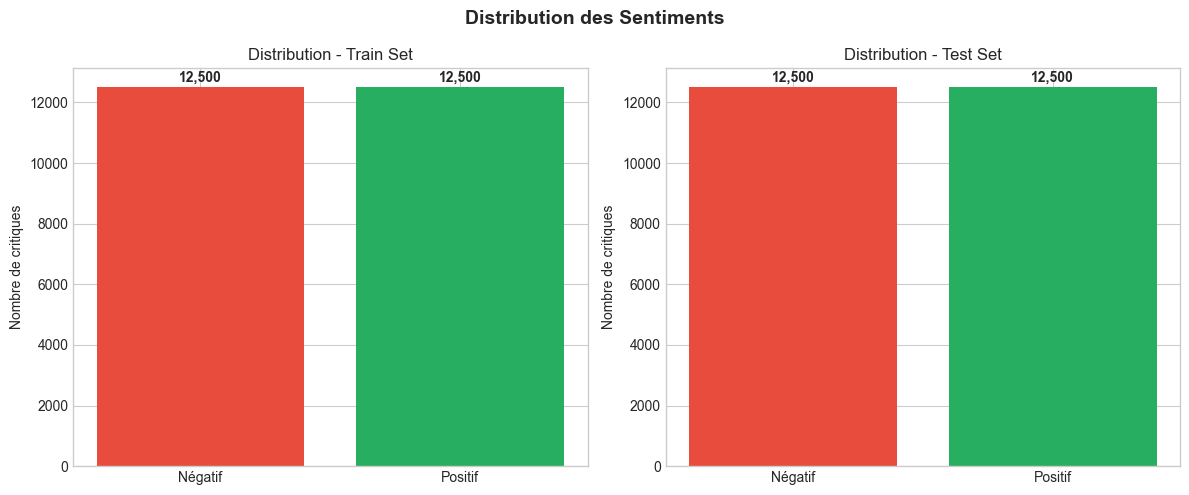

Train - Ratio positif : 50.0%
Test  - Ratio positif : 50.0%

✓ Dataset parfaitement équilibré (50/50)


In [6]:
# Distribution des labels
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Train set
train_counts = df_train['label'].value_counts().sort_index()
axes[0].bar(['Négatif', 'Positif'], train_counts.values, color=['#e74c3c', '#27ae60'])
axes[0].set_title('Distribution - Train Set')
axes[0].set_ylabel('Nombre de critiques')
for i, v in enumerate(train_counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

# Test set
test_counts = df_test['label'].value_counts().sort_index()
axes[1].bar(['Négatif', 'Positif'], test_counts.values, color=['#e74c3c', '#27ae60'])
axes[1].set_title('Distribution - Test Set')
axes[1].set_ylabel('Nombre de critiques')
for i, v in enumerate(test_counts.values):
    axes[1].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

plt.suptitle('Distribution des Sentiments', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Statistiques
print(f"Train - Ratio positif : {df_train['label'].mean():.1%}")
print(f"Test  - Ratio positif : {df_test['label'].mean():.1%}")
print("\n✓ Dataset parfaitement équilibré (50/50)")

## 5. Analyse de la Longueur des Textes

Étude de la distribution des longueurs pour dimensionner correctement le modèle BERT.

In [7]:
# Calculer la longueur des textes (en caractères et en mots)
df_train['char_length'] = df_train['text'].apply(len)
df_train['word_count'] = df_train['text'].apply(lambda x: len(x.split()))

# Statistiques descriptives
print("LONGUEUR EN CARACTÈRES")
print(df_train['char_length'].describe().round(0))

print("\nLONGUEUR EN MOTS")
print(df_train['word_count'].describe().round(0))

LONGUEUR EN CARACTÈRES
count    25000.0
mean      1325.0
std       1003.0
min         52.0
25%        702.0
50%        979.0
75%       1614.0
max      13704.0
Name: char_length, dtype: float64

LONGUEUR EN MOTS
count    25000.0
mean       234.0
std        174.0
min         10.0
25%        127.0
50%        174.0
75%        284.0
max       2470.0
Name: word_count, dtype: float64


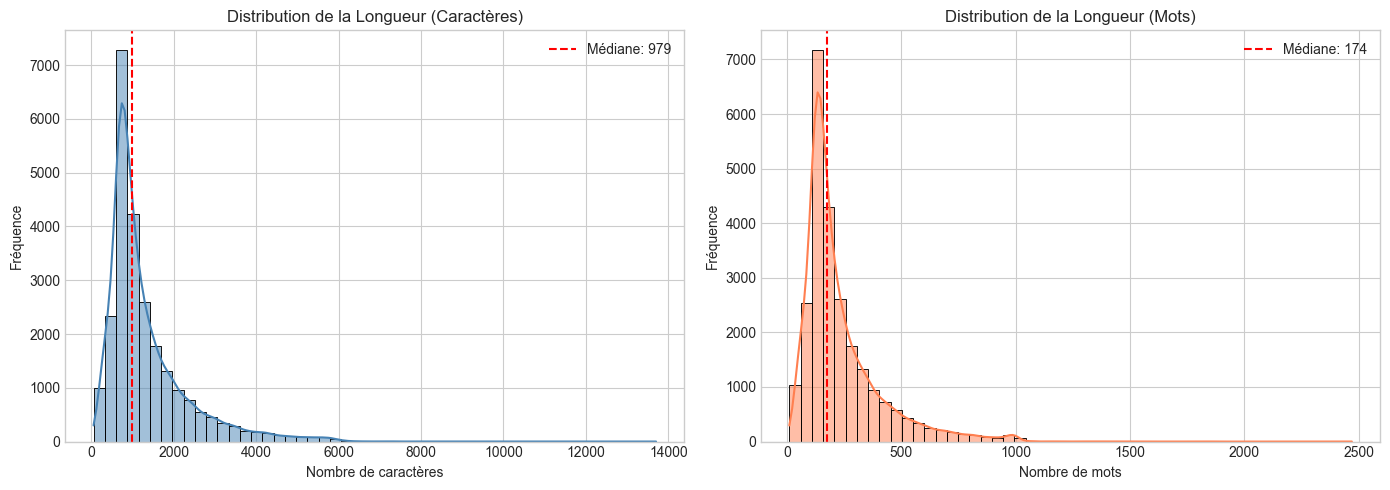

In [8]:
# Visualisation des distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution en caractères
sns.histplot(df_train['char_length'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].axvline(x=df_train['char_length'].median(), color='red', linestyle='--', 
                label=f"Médiane: {df_train['char_length'].median():,.0f}")
axes[0].set_title('Distribution de la Longueur (Caractères)')
axes[0].set_xlabel('Nombre de caractères')
axes[0].set_ylabel('Fréquence')
axes[0].legend()

# Distribution en mots
sns.histplot(df_train['word_count'], bins=50, kde=True, ax=axes[1], color='coral')
axes[1].axvline(x=df_train['word_count'].median(), color='red', linestyle='--',
                label=f"Médiane: {df_train['word_count'].median():,.0f}")
axes[1].set_title('Distribution de la Longueur (Mots)')
axes[1].set_xlabel('Nombre de mots')
axes[1].set_ylabel('Fréquence')
axes[1].legend()

plt.tight_layout()
plt.show()

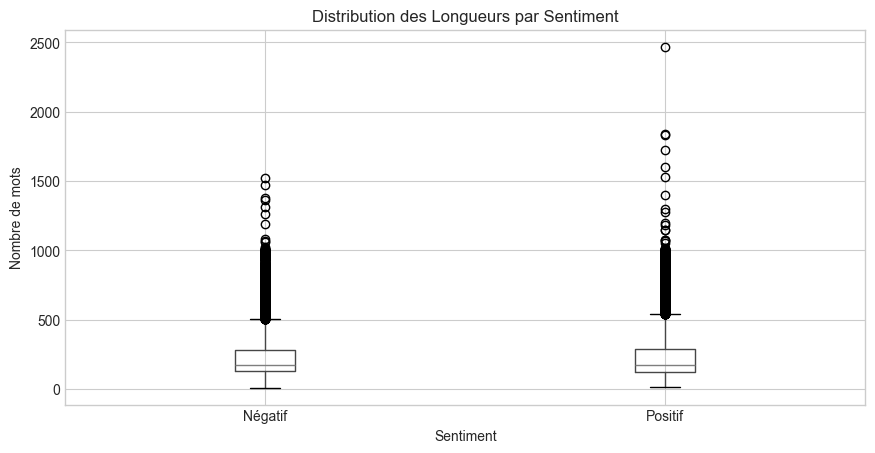

Longueur moyenne (mots) par sentiment :
{0: 231.0, 1: 237.0}

→ Les critiques positives et négatives ont des longueurs similaires


In [9]:
# Longueur par sentiment
fig, ax = plt.subplots(figsize=(10, 5))

df_train.boxplot(column='word_count', by='label', ax=ax)
ax.set_xticklabels(['Négatif', 'Positif'])
ax.set_xlabel('Sentiment')
ax.set_ylabel('Nombre de mots')
ax.set_title('Distribution des Longueurs par Sentiment')
plt.suptitle('')  # Supprimer le titre automatique
plt.show()

# Statistiques par sentiment
print("Longueur moyenne (mots) par sentiment :")
print(df_train.groupby('label')['word_count'].mean().round(0).to_dict())
print("\n→ Les critiques positives et négatives ont des longueurs similaires")

In [10]:
# Analyse pour BERT (limite de 512 tokens)
# Approximation : 1 token ≈ 0.75 mot pour l'anglais
BERT_TOKEN_LIMIT = 512
APPROX_WORD_LIMIT = int(BERT_TOKEN_LIMIT * 0.75)  # ~384 mots

texts_above_limit = (df_train['word_count'] > APPROX_WORD_LIMIT).sum()
pct_above = texts_above_limit / len(df_train) * 100

print(f"Limite BERT : ~{APPROX_WORD_LIMIT} mots (512 tokens)")
print(f"Critiques dépassant cette limite : {texts_above_limit:,} ({pct_above:.1f}%)")
print(f"\n→ Une troncation à 128-256 tokens sera nécessaire pour ~{pct_above:.0f}% des textes")

Limite BERT : ~384 mots (512 tokens)
Critiques dépassant cette limite : 3,614 (14.5%)

→ Une troncation à 128-256 tokens sera nécessaire pour ~14% des textes


## 6. Sauvegarde des Données

Export des données pour les notebooks suivants.

In [11]:
import os

# Créer le dossier data s'il n'existe pas
os.makedirs('../data', exist_ok=True)

# Sauvegarder les DataFrames (sans les colonnes calculées)
df_train[['text', 'label']].to_csv('../data/train_raw.csv', index=False)
df_test[['text', 'label']].to_csv('../data/test_raw.csv', index=False)

print("Fichiers sauvegardés :")
print(f"  - ../data/train_raw.csv ({len(df_train):,} lignes)")
print(f"  - ../data/test_raw.csv ({len(df_test):,} lignes)")

Fichiers sauvegardés :
  - ../data/train_raw.csv (25,000 lignes)
  - ../data/test_raw.csv (25,000 lignes)


## Conclusion

### Caractéristiques du Dataset

| Propriété | Valeur |
|-----------|--------|
| Taille totale | 50,000 critiques |
| Train / Test | 25,000 / 25,000 |
| Équilibre des classes | 50% positif, 50% négatif |
| Longueur moyenne | ~230 mots par critique |
| Longueur médiane | ~170 mots par critique |

### Points clés pour la modélisation

1. **Dataset équilibré** : Pas besoin de techniques de rééchantillonnage
2. **Textes longs** : ~25% des textes dépassent 384 mots, une troncation sera nécessaire
3. **Pas de valeurs manquantes** : Données propres et complètes
4. **Longueurs similaires** : Pas de différence significative entre positif et négatif

### Prochaines étapes
- Notebook 02 : Prétraitement et nettoyage des textes
- Notebook 03 : Entraînement du modèle BERT